The objective of this notebook is to analyze customer behavior using the engineered customer-level dataset and identify meaningful patterns within the customer base.

The analysis focuses on two main tasks:
    
    1)Anomaly Detection
    2)Customer Segmentation

# Transaction Level

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
customer_df = pd.read_csv('..\data\processed\customer_features.csv')

customer_df.head()

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\user\AppData\Local\Temp\ipykernel_7668\2209893163.py:1: SyntaxWarning: invalid escape sequence '\d'
  customer_df = pd.read_csv('..\data\processed\customer_features.csv')


,ACCOUNTNO,CUSTOMER_AGE,GENDER,DEPENDENT_COUNT,EDUCATION_LEVEL,MARITAL_STATUS,INCOME_CATEGORY,CARD_CATEGORY,MONTHS_ON_BOOK,TOTAL_RELATIONSHIP_COUNT,MONTHS_INACTIVE_12_MON,CONTACTS_COUNT_12_MON,CREDIT_LIMIT,TOTAL_REVOLVING_BAL,total_deposit,total_withdrawal,average_deposit,average_withdrawal,transaction_count,net_flow
0,708082083,45,F,3,High School,Married,Less than $40K,Blue,36,4,3,3,3544.0,1661,1.200000e+04,0.00,1.200000e+04,0.000000e+00,1,12000.00
1,708083283,58,M,0,Unknown,Single,$40K - $60K,Blue,45,3,1,3,3421.0,2517,3.118584e+07,68970583.09,1.299410e+06,2.873774e+06,24,-37784743.05
2,708084558,46,M,3,Doctorate,Divorced,$80K - $120K,Blue,38,6,3,3,8258.0,1771,1.376231e+08,45033176.38,4.587436e+06,1.501106e+06,30,92589913.91
3,708085458,34,F,2,Uneducated,Single,Less than $40K,Blue,24,6,2,2,1438.3,0,0.000000e+00,233851.00,0.000000e+00,2.338510e+05,1,-233851.00
4,708098133,32,F,0,Graduate,Married,Less than $40K,Blue,19,6,1,0,2834.0,1418,3.000000e+05,0.00,3.000000e+05,0.000000e+00,1,300000.00


In [6]:
customer_df.shape

(7260, 20)

In [7]:
customer_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7260 entries, 0 to 7259
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ACCOUNTNO                 7260 non-null   int64  
 1   CUSTOMER_AGE              7260 non-null   int64  
 2   GENDER                    7260 non-null   str    
 3   DEPENDENT_COUNT           7260 non-null   int64  
 4   EDUCATION_LEVEL           7260 non-null   str    
 5   MARITAL_STATUS            7260 non-null   str    
 6   INCOME_CATEGORY           7260 non-null   str    
 7   CARD_CATEGORY             7260 non-null   str    
 8   MONTHS_ON_BOOK            7260 non-null   int64  
 9   TOTAL_RELATIONSHIP_COUNT  7260 non-null   int64  
 10  MONTHS_INACTIVE_12_MON    7260 non-null   int64  
 11  CONTACTS_COUNT_12_MON     7260 non-null   int64  
 12  CREDIT_LIMIT              7260 non-null   float64
 13  TOTAL_REVOLVING_BAL       7260 non-null   int64  
 14  total_deposit      

## Data Visualization

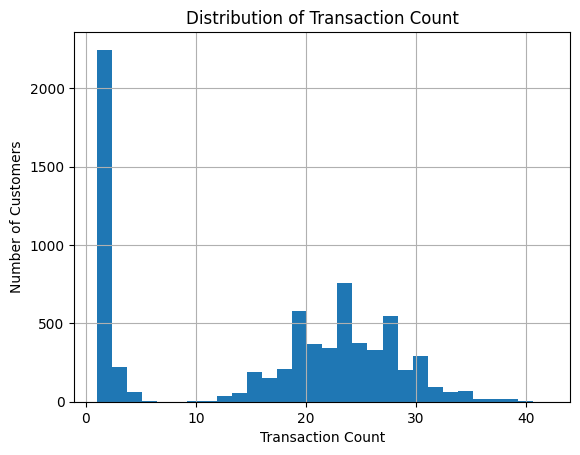

In [8]:
# Transaction count distribution
plt.figure()
customer_df['transaction_count'].hist(bins=30)
plt.title('Distribution of Transaction Count')
plt.xlabel('Transaction Count')
plt.ylabel("Number of Customers")
plt.show()

Most customers perform a relatively small number of transactions, while a smaller group of customers shows higher transactional activity. The distribution suggests that customer activity varies significantly across the population, with a few customers demonstrating unusually high transaction frequency. These highly active customers could potentially represent behavioral anomalies.

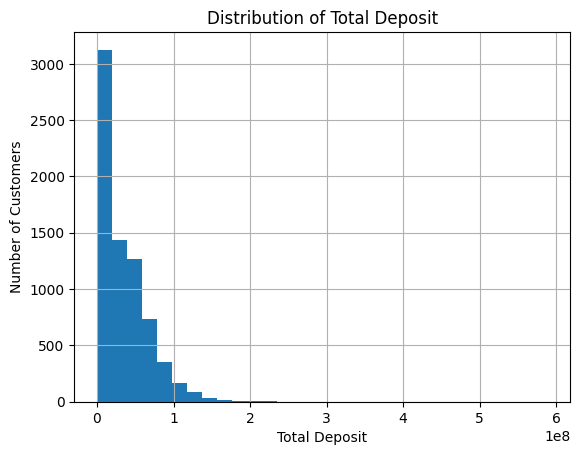

In [9]:
# Total Deposit Distribution
plt.figure()
customer_df['total_deposit'].hist(bins=30)
plt.title('Distribution of Total Deposit')
plt.xlabel('Total Deposit')
plt.ylabel("Number of Customers")
plt.show()

The total deposit distribution is highly right-skewed, indicating that the majority of customers deposit relatively small amounts of money, while a small subset of customers deposit significantly larger amounts. These extreme values may represent high-value customers or potential anomalies depending on their overall profile.

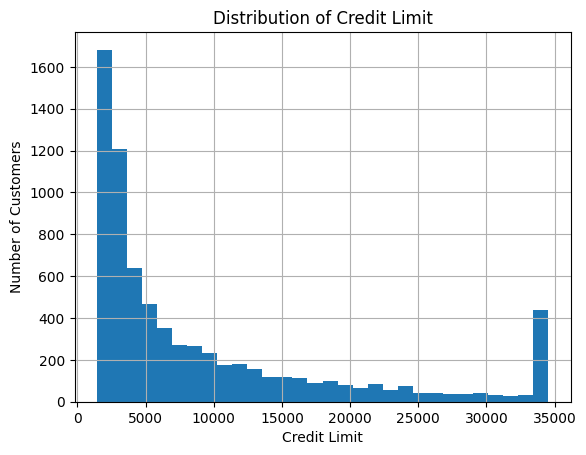

In [10]:
# Credit Limit Distribution
plt.figure()
customer_df['CREDIT_LIMIT'].hist(bins=30)
plt.title('Distribution of Credit Limit')
plt.xlabel('Credit Limit')
plt.ylabel("Number of Customers")
plt.show()

The credit limit distribution shows that most customers fall within a moderate credit range, while a small number of customers have significantly higher limits. These high-credit customers may represent premium banking clients or individuals with strong credit profiles.

## Ml Data Preprocessing

In [11]:
categorical_features = [
    "GENDER",
    "EDUCATION_LEVEL",
    "MARITAL_STATUS",
    "INCOME_CATEGORY",
    "CARD_CATEGORY"
]

numerical_features = [
    "CUSTOMER_AGE",
    "DEPENDENT_COUNT",
    "MONTHS_ON_BOOK",
    "TOTAL_RELATIONSHIP_COUNT",
    "MONTHS_INACTIVE_12_MON",
    "CONTACTS_COUNT_12_MON",
    "CREDIT_LIMIT",
    "TOTAL_REVOLVING_BAL",
    "total_deposit",
    "total_withdrawal",
    "average_deposit",
    "average_withdrawal",
    "transaction_count",
    "net_flow"
]

In [12]:
# Encoding categorical features
customer_encoded = pd.get_dummies(
    customer_df,
    columns=categorical_features,
    drop_first=True
)

In [13]:
customer_encoded.head()

,ACCOUNTNO,CUSTOMER_AGE,DEPENDENT_COUNT,MONTHS_ON_BOOK,TOTAL_RELATIONSHIP_COUNT,MONTHS_INACTIVE_12_MON,CONTACTS_COUNT_12_MON,CREDIT_LIMIT,TOTAL_REVOLVING_BAL,total_deposit,...,MARITAL_STATUS_Married,MARITAL_STATUS_Single,MARITAL_STATUS_Unknown,INCOME_CATEGORY_$40K - $60K,INCOME_CATEGORY_$60K - $80K,INCOME_CATEGORY_$80K - $120K,INCOME_CATEGORY_Less than $40K,CARD_CATEGORY_Gold,CARD_CATEGORY_Platinum,CARD_CATEGORY_Silver
0,708082083,45,3,36,4,3,3,3544.0,1661,1.200000e+04,...,True,False,False,False,False,False,True,False,False,False
1,708083283,58,0,45,3,1,3,3421.0,2517,3.118584e+07,...,False,True,False,True,False,False,False,False,False,False
2,708084558,46,3,38,6,3,3,8258.0,1771,1.376231e+08,...,False,False,False,False,False,True,False,False,False,False
3,708085458,34,2,24,6,2,2,1438.3,0,0.000000e+00,...,False,True,False,False,False,False,True,False,False,False
4,708098133,32,0,19,6,1,0,2834.0,1418,3.000000e+05,...,True,False,False,False,False,False,True,False,False,False


In [14]:
X = customer_encoded.drop(["ACCOUNTNO"], axis=1)

In [15]:
X.shape

(7260, 31)

In [16]:
X.head()

,CUSTOMER_AGE,DEPENDENT_COUNT,MONTHS_ON_BOOK,TOTAL_RELATIONSHIP_COUNT,MONTHS_INACTIVE_12_MON,CONTACTS_COUNT_12_MON,CREDIT_LIMIT,TOTAL_REVOLVING_BAL,total_deposit,total_withdrawal,...,MARITAL_STATUS_Married,MARITAL_STATUS_Single,MARITAL_STATUS_Unknown,INCOME_CATEGORY_$40K - $60K,INCOME_CATEGORY_$60K - $80K,INCOME_CATEGORY_$80K - $120K,INCOME_CATEGORY_Less than $40K,CARD_CATEGORY_Gold,CARD_CATEGORY_Platinum,CARD_CATEGORY_Silver
0,45,3,36,4,3,3,3544.0,1661,1.200000e+04,0.00,...,True,False,False,False,False,False,True,False,False,False
1,58,0,45,3,1,3,3421.0,2517,3.118584e+07,68970583.09,...,False,True,False,True,False,False,False,False,False,False
2,46,3,38,6,3,3,8258.0,1771,1.376231e+08,45033176.38,...,False,False,False,False,False,True,False,False,False,False
3,34,2,24,6,2,2,1438.3,0,0.000000e+00,233851.00,...,False,True,False,False,False,False,True,False,False,False
4,32,0,19,6,1,0,2834.0,1418,3.000000e+05,0.00,...,True,False,False,False,False,False,True,False,False,False


## Scaling the Feature

In [17]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [18]:
X_scaled.shape

(7260, 31)

## Isolation Forest Ml Model

In [19]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(
    n_estimators=200,
    contamination=0.02,
    random_state=42
)

model.fit(X_scaled)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",200
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.02
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [20]:
customer_df["anomaly_score"] = model.decision_function(X_scaled)
customer_df["anomaly"] = model.predict(X_scaled)

In [21]:
customer_df["anomaly"].value_counts()

anomaly
 1    7114
-1     146
Name: count, dtype: int64

## Analyze Anomilous Customer

In [22]:
anomalies = customer_df[customer_df["anomaly"] == -1]
anomalies.head()

,ACCOUNTNO,CUSTOMER_AGE,GENDER,DEPENDENT_COUNT,EDUCATION_LEVEL,MARITAL_STATUS,INCOME_CATEGORY,CARD_CATEGORY,MONTHS_ON_BOOK,TOTAL_RELATIONSHIP_COUNT,...,CREDIT_LIMIT,TOTAL_REVOLVING_BAL,total_deposit,total_withdrawal,average_deposit,average_withdrawal,transaction_count,net_flow,anomaly_score,anomaly
30,708195633,40,M,2,High School,Unknown,$80K - $120K,Silver,32,5,...,34516.0,1182,6.245892e+07,9.471389e+07,2.715605e+06,4.117995e+06,23,-3.225497e+07,-0.001900,-1
48,708248358,42,M,4,Graduate,Unknown,$60K - $80K,Silver,30,3,...,29937.0,0,5.377014e+07,1.518280e+07,4.136165e+06,1.167908e+06,13,3.858735e+07,-0.003402,-1
99,708428958,39,M,2,Unknown,Single,$80K - $120K,Gold,33,1,...,34516.0,0,4.977070e+07,8.673255e+07,1.914258e+06,3.335867e+06,26,-3.696185e+07,-0.017627,-1
149,708582858,38,M,3,Graduate,Single,$60K - $80K,Blue,25,3,...,18293.0,0,5.889896e+08,1.055748e+08,2.030999e+07,3.640510e+06,29,4.834148e+08,-0.008161,-1
170,708662583,41,M,3,Unknown,Married,$60K - $80K,Silver,29,1,...,27945.0,0,1.217342e+08,1.683966e+07,5.292792e+06,7.321592e+05,23,1.048945e+08,-0.015152,-1


In [23]:
anomalies.shape

(146, 22)

In [24]:
anomalies.describe()

,ACCOUNTNO,CUSTOMER_AGE,DEPENDENT_COUNT,MONTHS_ON_BOOK,TOTAL_RELATIONSHIP_COUNT,MONTHS_INACTIVE_12_MON,CONTACTS_COUNT_12_MON,CREDIT_LIMIT,TOTAL_REVOLVING_BAL,total_deposit,total_withdrawal,average_deposit,average_withdrawal,transaction_count,net_flow,anomaly_score,anomaly
count,1.460000e+02,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000,1.460000e+02,1.460000e+02,1.460000e+02,1.460000e+02,146.000000,1.460000e+02,146.000000,146.0
mean,7.422918e+08,46.335616,2.253425,36.321918,3.061644,2.465753,2.554795,24516.366438,1172.267123,7.084106e+07,8.362547e+07,3.062759e+06,5.602876e+06,21.582192,-1.278441e+07,-0.013742,-1.0
std,3.940739e+07,9.121613,1.618052,9.552710,1.770340,1.292762,1.275935,11964.686851,857.636361,8.143219e+07,8.979118e+07,3.171482e+06,1.926171e+07,9.640258,1.241466e+08,0.012267,0.0
min,7.081956e+08,26.000000,0.000000,13.000000,1.000000,1.000000,0.000000,1438.300000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000,-4.632072e+08,-0.056669,-1.0
25%,7.126932e+08,41.000000,1.000000,30.000000,1.000000,1.000000,2.000000,15552.500000,53.500000,2.425503e+07,1.545123e+07,1.278684e+06,9.134202e+05,18.250000,-6.228151e+07,-0.020011,-1.0
50%,7.178527e+08,46.000000,2.000000,36.000000,3.000000,2.000000,3.000000,32175.000000,1281.000000,5.252024e+07,5.561910e+07,2.180765e+06,2.654631e+06,24.000000,-4.171282e+06,-0.009980,-1.0
75%,7.789576e+08,52.000000,4.000000,41.750000,5.000000,3.000000,3.000000,34516.000000,1960.750000,1.020567e+08,1.218052e+08,4.099668e+06,6.185798e+06,27.750000,4.256311e+07,-0.004861,-1.0
max,8.262459e+08,65.000000,5.000000,56.000000,6.000000,6.000000,6.000000,34516.000000,2517.000000,5.889896e+08,4.632072e+08,2.030999e+07,2.316036e+08,40.000000,5.090471e+08,-0.000024,-1.0


In [25]:
customer_df.describe()

,ACCOUNTNO,CUSTOMER_AGE,DEPENDENT_COUNT,MONTHS_ON_BOOK,TOTAL_RELATIONSHIP_COUNT,MONTHS_INACTIVE_12_MON,CONTACTS_COUNT_12_MON,CREDIT_LIMIT,TOTAL_REVOLVING_BAL,total_deposit,total_withdrawal,average_deposit,average_withdrawal,transaction_count,net_flow,anomaly_score,anomaly
count,7.260000e+03,7260.000000,7260.000000,7260.000000,7260.000000,7260.000000,7260.000000,7260.000000,7260.000000,7.260000e+03,7.260000e+03,7.260000e+03,7.260000e+03,7260.000000,7.260000e+03,7260.000000,7260.000000
mean,7.397776e+08,46.280579,2.378926,35.900826,3.802066,2.332782,2.461433,9245.563237,1165.876309,3.284989e+07,3.311180e+07,1.613557e+06,1.615683e+06,16.005647,-2.619032e+05,0.078119,0.959780
std,3.706911e+07,7.803531,1.288444,7.824397,1.557484,1.011029,1.107041,9453.301436,811.269991,3.616862e+07,3.950714e+07,6.586157e+06,3.357036e+06,11.304309,4.258235e+07,0.030390,0.280774
min,7.080821e+08,26.000000,0.000000,13.000000,1.000000,0.000000,0.000000,1438.300000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000,-4.632072e+08,-0.056669,-1.000000
25%,7.130999e+08,41.000000,1.000000,31.000000,3.000000,2.000000,2.000000,2628.000000,459.500000,2.050000e+05,1.608863e+05,1.359737e+05,9.046365e+04,2.000000,-1.160515e+07,0.061590,1.000000
50%,7.181093e+08,46.000000,2.000000,36.000000,4.000000,2.000000,2.000000,4979.000000,1280.500000,2.721927e+07,2.227488e+07,1.299346e+06,1.111319e+06,20.000000,3.000000e+03,0.082346,1.000000
75%,7.781869e+08,52.000000,3.000000,40.000000,5.000000,3.000000,3.000000,12291.750000,1777.000000,5.209653e+07,5.155222e+07,2.293308e+06,2.303478e+06,25.000000,1.489966e+07,0.099419,1.000000
max,8.282989e+08,73.000000,5.000000,56.000000,6.000000,6.000000,6.000000,34516.000000,2517.000000,5.889896e+08,4.750524e+08,5.448000e+08,2.316036e+08,42.000000,5.448000e+08,0.149559,1.000000


In [26]:
customer_df.groupby("anomaly")[[

    "total_deposit",
    "total_withdrawal",
    "transaction_count",
    "CREDIT_LIMIT",
    "TOTAL_REVOLVING_BAL"
]
].mean()

,total_deposit,total_withdrawal,transaction_count,CREDIT_LIMIT,TOTAL_REVOLVING_BAL
anomaly,,,,,
-1,7.084106e+07,8.362547e+07,21.582192,24516.366438,1172.267123
1,3.207020e+07,3.207511e+07,15.891200,8932.161878,1165.745150


The Isolation Forest model identified approximately 2% of customers as anomalous. These customers exhibit significantly higher financial activity compared to the general population. On average, anomalous customers deposit more than twice the amount of normal customers, perform more transactions, and possess substantially higher credit limits. This suggests that the model successfully captures customers whose financial behavior deviates strongly from the typical customer profile.

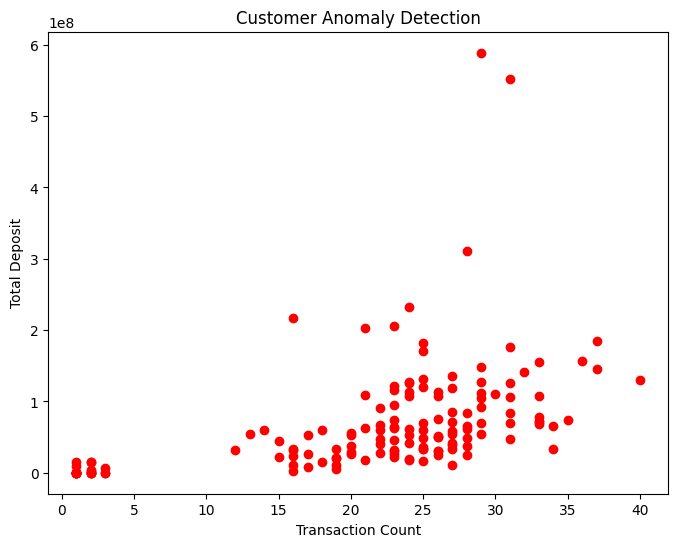

In [27]:
plt.figure(figsize=(8,6))

# normal = customer_df[customer_df["anomaly"] == 1]
anomaly = customer_df[customer_df["anomaly"] == -1]

# plt.scatter(
#     normal["transaction_count"],
#     normal["total_deposit"],
#     color="blue",
#     alpha=0.3,
#     label="Normal Customers"
# )

plt.scatter(
    anomaly["transaction_count"],
    anomaly["total_deposit"],
    color="red",
    label="Anomalous Customers"
)

plt.xlabel("Transaction Count")
plt.ylabel("Total Deposit")
plt.title("Customer Anomaly Detection")

# plt.legend()

plt.show()

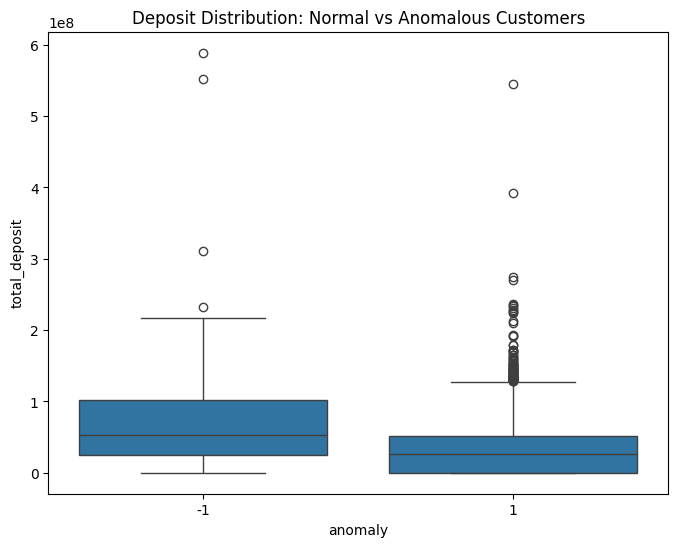

In [28]:
plt.figure(figsize=(8,6))
sns.boxplot(x="anomaly", y="total_deposit", data=customer_df)

plt.title("Deposit Distribution: Normal vs Anomalous Customers")
plt.show()

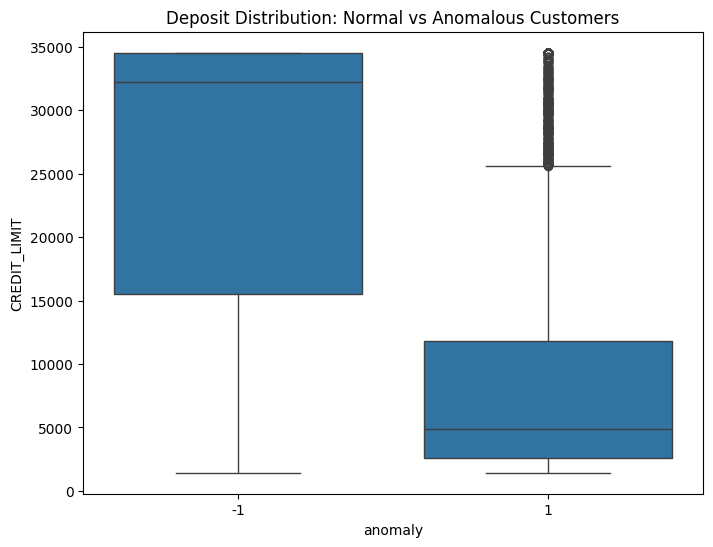

In [29]:
plt.figure(figsize=(8,6))
sns.boxplot(x="anomaly", y="CREDIT_LIMIT", data=customer_df)

plt.title("Deposit Distribution: Normal vs Anomalous Customers")
plt.show()

Anomalous customers tend to have BOTH high deposits AND high credit limits

In [30]:
anomalies[["INCOME_CATEGORY", "total_deposit"]].sort_values("total_deposit", ascending=False).head(10)

,INCOME_CATEGORY,total_deposit
149,$60K - $80K,5.889896e+08
1104,$60K - $80K,5.527597e+08
5303,$80K - $120K,3.107582e+08
653,$40K - $60K,2.325096e+08
4993,$60K - $80K,2.165243e+08
2577,$60K - $80K,2.053183e+08
4919,$60K - $80K,2.022668e+08
4714,$40K - $60K,1.847767e+08
1869,$60K - $80K,1.819821e+08
6867,$40K - $60K,1.764700e+08


# Customer Profing K-Means 

In [31]:
clustering_features = [
    'total_deposit',
    'total_withdrawal',
    'average_deposit',
    'average_withdrawal',
    'transaction_count',
    'net_flow',
    'CREDIT_LIMIT',
    'TOTAL_REVOLVING_BAL',
    'MONTHS_ON_BOOK',
    'TOTAL_RELATIONSHIP_COUNT',
    'MONTHS_INACTIVE_12_MON',
    'CONTACTS_COUNT_12_MON'
]

X_cluster =  customer_df[clustering_features].copy()
X_cluster.head()

,total_deposit,total_withdrawal,average_deposit,average_withdrawal,transaction_count,net_flow,CREDIT_LIMIT,TOTAL_REVOLVING_BAL,MONTHS_ON_BOOK,TOTAL_RELATIONSHIP_COUNT,MONTHS_INACTIVE_12_MON,CONTACTS_COUNT_12_MON
0,1.200000e+04,0.00,1.200000e+04,0.000000e+00,1,12000.00,3544.0,1661,36,4,3,3
1,3.118584e+07,68970583.09,1.299410e+06,2.873774e+06,24,-37784743.05,3421.0,2517,45,3,1,3
2,1.376231e+08,45033176.38,4.587436e+06,1.501106e+06,30,92589913.91,8258.0,1771,38,6,3,3
3,0.000000e+00,233851.00,0.000000e+00,2.338510e+05,1,-233851.00,1438.3,0,24,6,2,2
4,3.000000e+05,0.00,3.000000e+05,0.000000e+00,1,300000.00,2834.0,1418,19,6,1,0


In [32]:
X_cluster.info()

<class 'pandas.DataFrame'>
RangeIndex: 7260 entries, 0 to 7259
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   total_deposit             7260 non-null   float64
 1   total_withdrawal          7260 non-null   float64
 2   average_deposit           7260 non-null   float64
 3   average_withdrawal        7260 non-null   float64
 4   transaction_count         7260 non-null   int64  
 5   net_flow                  7260 non-null   float64
 6   CREDIT_LIMIT              7260 non-null   float64
 7   TOTAL_REVOLVING_BAL       7260 non-null   int64  
 8   MONTHS_ON_BOOK            7260 non-null   int64  
 9   TOTAL_RELATIONSHIP_COUNT  7260 non-null   int64  
 10  MONTHS_INACTIVE_12_MON    7260 non-null   int64  
 11  CONTACTS_COUNT_12_MON     7260 non-null   int64  
dtypes: float64(6), int64(6)
memory usage: 680.8 KB


## Scaling the Clustering Features

In [33]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)

## Finding the Best Number of Clusters Using Elbow Methode

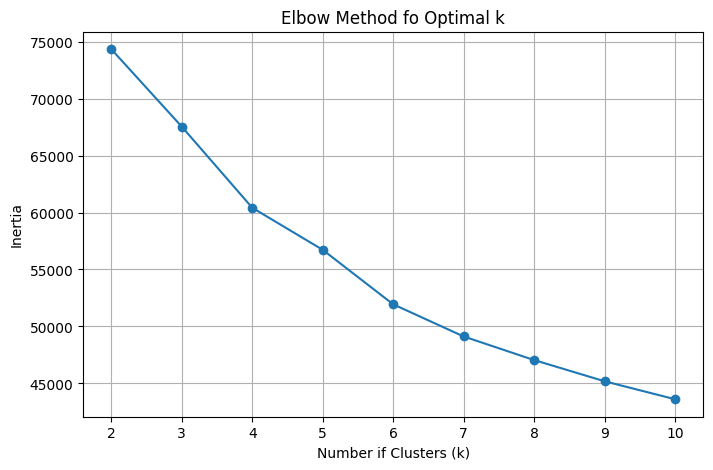

In [34]:
from sklearn.cluster import KMeans

inertia = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(k_values, inertia, marker = 'o')
plt.xlabel("Number if Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method fo Optimal k")
plt.grid(True)
plt.show()

The elbow curve shows a strong decrease in inertia up to around k=5–6, after which the improvement becomes marginal. Therefore, k=5 was selected as a balance between model performance and interpretability

## Kmeans Model

In [ ]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
customer_df["cluster"]= kmeans.fit_predict(X_cluster_scaled)


In [61]:
customer_df["cluster"].value_counts().sort_index()

cluster
0    2421
1    1232
2     963
3    2643
4       1
Name: count, dtype: int64

## Profile Each Cluster

In [62]:
cluster_profile = customer_df.groupby('cluster')[[
    'total_deposit',
    'total_withdrawal',
    'average_deposit',
    'average_withdrawal',
    'transaction_count',
    'net_flow',
    'CREDIT_LIMIT',
    'TOTAL_REVOLVING_BAL'
]].mean()

cluster_profile

,total_deposit,total_withdrawal,average_deposit,average_withdrawal,transaction_count,net_flow,CREDIT_LIMIT,TOTAL_REVOLVING_BAL
cluster,,,,,,,,
0,1.231882e+06,1.584018e+06,3.582822e+05,4.102107e+05,2.251962,-3.521356e+05,4591.698389,1130.892193
1,3.573652e+07,9.592442e+07,1.441499e+06,4.194652e+06,24.542208,-6.018789e+07,8465.597240,1149.361201
2,3.520013e+07,3.022471e+07,1.983786e+06,1.909948e+06,17.747664,4.975419e+06,28766.201454,1210.480789
3,5.941654e+07,3.377656e+07,2.503183e+06,1.411140e+06,23.995838,2.563998e+07,6762.535452,1189.809308
4,5.448000e+08,0.000000e+00,5.448000e+08,0.000000e+00,1.000000,5.448000e+08,1438.300000,0.000000


| Cluster | Segment Name                      |
| ------- | --------------------------------- |
| 0       | Moderate activity customers       |
| 1       | High withdrawal customers         |
| 2       | High value customers              |
| 3       | Active high transaction customers |
| 4       | Extreme outlier customer          |


## Combine Anomaly with Cluster

In [63]:
pd.crosstab(customer_df["cluster"], customer_df["anomaly"])

anomaly,-1,1
cluster,,
0,6,2415
1,43,1189
2,74,889
3,23,2620
4,0,1


## Visualization of Cluster

we will apply PCA to reduce the dimention of dataset to 2 dimension so we can viusalize

In [64]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster_scaled)

In [65]:
pca_df = pd.DataFrame(
    X_pca,
    columns=['PC1', "PC2"]
)

pca_df["cluster"] = customer_df["cluster"]
pca_df["anomaly"] = customer_df["anomaly"]

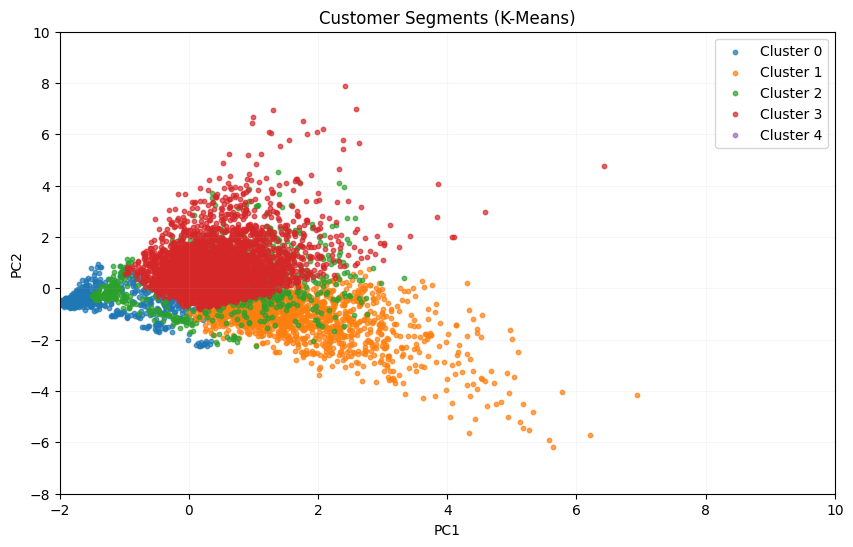

In [74]:
plt.figure(figsize=(10,6))

for cluster in sorted(pca_df["cluster"].unique()):
    
    cluster_data = pca_df[pca_df["cluster"] == cluster]
    
    plt.scatter(
        cluster_data["PC1"],
        cluster_data["PC2"],
        s=10,
        alpha=0.7,
        label=f"Cluster {cluster}"
    )

plt.title("Customer Segments (K-Means)")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.xlim(-2, 10)
plt.ylim(-8, 10)

plt.legend()
plt.grid(alpha=0.1)

plt.show()

<Figure size 1000x600 with 0 Axes>

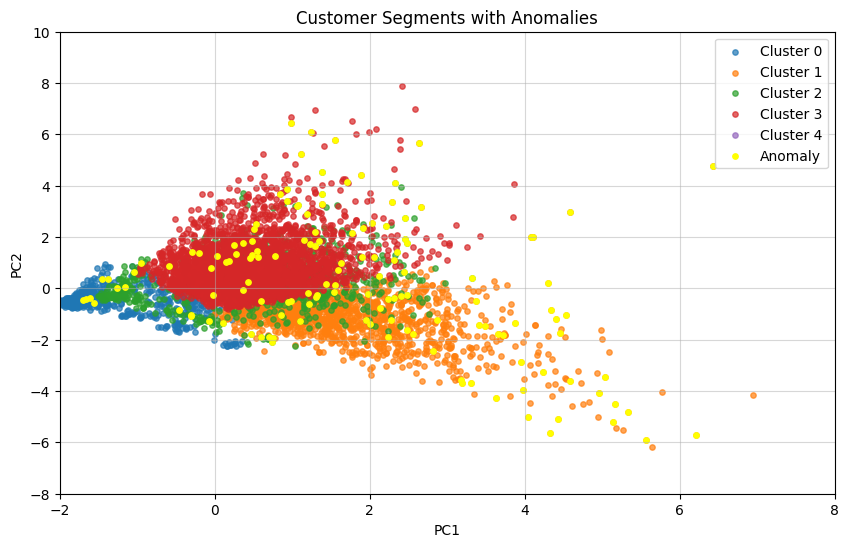

In [79]:
plt.figure(figsize=(10,6))
plt.figure(figsize=(10,6))

for cluster in sorted(pca_df["cluster"].unique()):
    
    cluster_data = pca_df[pca_df["cluster"] == cluster]
    
    plt.scatter(
        cluster_data["PC1"],
        cluster_data["PC2"],
        s=15,
        alpha=0.7,
        label=f"Cluster {cluster}"
    )


# Highlight anomalies
plt.scatter(
    pca_df[pca_df['anomaly'] == -1]['PC1'],
    pca_df[pca_df['anomaly'] == -1]['PC2'],
    color='yellow',
    s=15,
    label='Anomaly'
)

plt.title("Customer Segments with Anomalies")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.xlim(-2, 8)
plt.ylim(-8, 10)

plt.legend()
plt.grid(alpha=0.5)

plt.show()



The PCA visualization provides a two-dimensional projection of the high-dimensional customer feature space. While clusters may appear partially overlapping in the 2D projection, the K-Means algorithm operates in the full feature space where separation between segments is clearer. Therefore, cluster interpretations are derived from the statistical profiles of each segment rather than the visual projection alone.

# Insight Section

Customer Behavior Segments

The clustering analysis identified five distinct customer segments based on their financial behavior.

Cluster	Segment Description

    0	Moderate activity customers
    1	High withdrawal customers
    2	High value customers
    3	Active high transaction customers
    4	Extreme outlier customer

These segments reveal clear behavioral patterns within the customer base.

    Cluster3 represents highly active customers with frequent transactions.

    Cluster2 contains financially strong customers with high deposits and credit limits.

    Cluster1 is characterized by large withdrawal activity.

# Conclusion



This analysis demonstrates how transaction level banking data can be transformed into meaningful customer behavioral profiles. By combining feature engineering, anomaly detection, and clustering techniques, the analysis reveals both typical customer segments and unusual financial behavior patterns.

Such insights can support fraud detection, customer segmentation strategies, and financial risk monitoring within banking systems.